In [51]:
import numpy as np
import pandas as pd
import plotly.express as px

In [52]:
pd.set_option('display.max_columns', None)

# Load Dataset

In [53]:
df = pd.read_csv('Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


# Data Exploration

In [54]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [55]:
# Check summary statistics for Numerical columns
df.describe().round(2)

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2.286000e+03,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,1.275338e+07,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,6.101210e+07,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,1.957932e+05,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.76,64.91,92.00,17.00,43.50,4.00,93.00,5.76,93.00,0.10,1766.95,1.386542e+06,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7.420359e+06,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1.293859e+09,27.70,28.60,0.95,20.70


In [56]:
# Check summary statistics for Categorical Columns
df.describe(include= 'object')

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [57]:
df.shape

(2938, 22)

In [58]:
# Check Missing Values by count
df.isna().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [59]:
# Check Missing Values by percentage
round(df.isna().mean() * 100, 2)

Country                             0.00
Year                                0.00
Status                              0.00
Life expectancy                     0.34
Adult Mortality                     0.34
infant deaths                       0.00
Alcohol                             6.60
percentage expenditure              0.00
Hepatitis B                        18.82
Measles                             0.00
 BMI                                1.16
under-five deaths                   0.00
Polio                               0.65
Total expenditure                   7.69
Diphtheria                          0.65
 HIV/AIDS                           0.00
GDP                                15.25
Population                         22.19
 thinness  1-19 years               1.16
 thinness 5-9 years                 1.16
Income composition of resources     5.68
Schooling                           5.55
dtype: float64

In [60]:
df.duplicated().sum()

0

# Data Cleaning

In [61]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

### In depth check for categorical columns

In [62]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Country', 'Status'], dtype='object')

In [63]:
for col in cat_cols:

    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print('-' * 100)

Country
193
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia (Plurinational State of)' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' "Côte d'Ivoire" 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia'
 "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia'
 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India'
 'Indonesia' 'Iran (Islamic R

### In depth check for Numerical Columns

In [64]:
# df.select_dtypes(exclude= 'object')
# df.select_dtypes(include= [int, float])
num_cols = df.select_dtypes(include= 'number').columns
num_cols

Index(['Year', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths',
       'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI',
       'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

In [65]:
for col in num_cols:

    px.histogram(data_frame= df, x= col, title= col).show()

In [66]:
df[df.infant_deaths == 0]['Country'].unique()

array(['Albania', 'Antigua and Barbuda', 'Austria', 'Bahamas', 'Bahrain',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bhutan',
       'Bosnia and Herzegovina', 'Brunei Darussalam', 'Bulgaria',
       'Cabo Verde', 'Cook Islands', 'Croatia', 'Cyprus', 'Czechia',
       'Denmark', 'Dominica', 'Estonia', 'Fiji', 'Finland', 'Greece',
       'Grenada', 'Guyana', 'Hungary', 'Iceland', 'Ireland', 'Israel',
       'Kiribati', 'Kuwait', 'Latvia', 'Lithuania', 'Luxembourg',
       'Maldives', 'Malta', 'Marshall Islands', 'Mauritius',
       'Micronesia (Federated States of)', 'Monaco', 'Montenegro',
       'Nauru', 'New Zealand', 'Niue', 'Norway', 'Palau', 'Portugal',
       'Qatar', 'Saint Kitts and Nevis', 'Saint Lucia',
       'Saint Vincent and the Grenadines', 'Samoa', 'San Marino',
       'Sao Tome and Principe', 'Seychelles', 'Singapore', 'Slovakia',
       'Slovenia', 'Solomon Islands', 'Suriname', 'Sweden', 'Switzerland',
       'The former Yugoslav republic of Macedonia', 'Tong

In [67]:
df[df.GDP < 0]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling


<Axes: xlabel='GDP', ylabel='Count'>

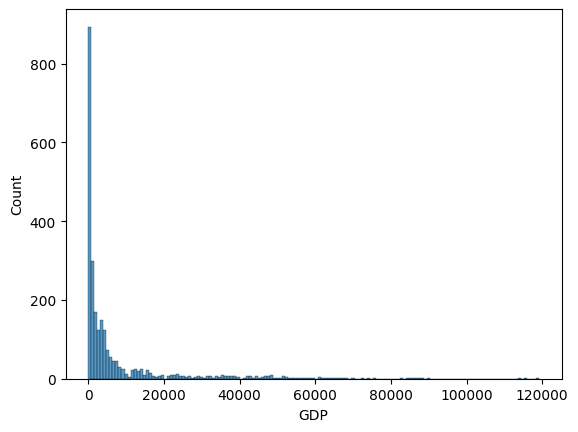

In [68]:
import seaborn as sns

sns.histplot(data= df, x= 'GDP')

In [69]:
px.histogram(data_frame= df, x= 'GDP', nbins= 40)

# Feature Engineering

In [70]:
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [71]:
df = df.rename(columns= {'thinness__1-19_years' : 'thinness__10-19_years'})
df

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__10-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


### Data Analysis

#### How does adult mortality relate to life expectancy ?

In [72]:
px.scatter(data_frame= df, x= 'Adult_Mortality', y= 'Life_expectancy', title= 'How does adult mortality relate to life expectancy ?')

In [73]:
df[['Life_expectancy', 'Adult_Mortality']].corr().round(2)

,Life_expectancy,Adult_Mortality
Life_expectancy,1.0,-0.7
Adult_Mortality,-0.7,1.0


#### Do developed and developing countries differ significantly in average life expectancy ?

In [74]:
le_per_status = df.groupby('Status')['Life_expectancy'].mean().round(1).reset_index()
le_per_status

,Status,Life_expectancy
0,Developed,79.2
1,Developing,67.1


In [75]:
px.bar(data_frame= le_per_status, x= 'Status', y= 'Life_expectancy'
       , labels= {'Status' : 'Country Type', 'Life_expectancy' : 'Average Life Expectancy'},
         title= 'Do developed and developing countries differ significantly in average life expectancy ?',
         text_auto= True)

#### What is the average Expenditure per Country per Year ?

In [76]:
status_per_year = df.groupby(['Status', 'Year'])['Total_expenditure'].mean().round(2).reset_index()
status_per_year

,Status,Year,Total_expenditure
0,Developed,2000,7.02
1,Developed,2001,6.82
2,Developed,2002,7.11
3,Developed,2003,7.14
4,Developed,2004,7.48
5,Developed,2005,7.50
6,Developed,2006,7.42
7,Developed,2007,7.35
8,Developed,2008,7.13
9,Developed,2009,8.35


In [77]:
px.bar(data_frame= status_per_year, x= 'Year', y= 'Total_expenditure', barmode= 'group',
        color= 'Status')

In [78]:
df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__10-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

### Data Preprocessing

In [79]:
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__10-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### Split Data into Input features and Target Feature

In [80]:
x = df.drop('Life_expectancy', axis= 1)
y = df['Life_expectancy']

### Split Data into Train and Test

In [81]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

### Categorical Data

In [82]:
x_train[cat_cols].isna().sum()

Country    0
Status     0
dtype: int64

In [83]:
x_train[cat_cols]

,Country,Status
456,Cabo Verde,Developing
462,Cabo Verde,Developing
2172,Saint Lucia,Developing
2667,Tunisia,Developing
381,Brunei Darussalam,Developing
...,...,...
1638,Malta,Developed
1095,Guinea-Bissau,Developing
1130,Haiti,Developing
1294,Italy,Developed


In [84]:
for col in cat_cols:

    print(col)
    print(x_train[col].nunique())

Country
191
Status
2


In [85]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop= 'first', sparse_output= False)

x_train['Status_developed']= ohe.fit_transform(x_train[['Status']])
x_test['Status_developed'] = ohe.transform(x_test[['Status']])

In [86]:
x_train.drop('Status', axis= 1, inplace= True)
x_test.drop('Status', axis= 1, inplace= True)

In [87]:
x_train.duplicated().sum()

0

In [88]:
x_test.duplicated().sum()

0

In [89]:
from category_encoders import BinaryEncoder

be = BinaryEncoder()

be_x_train = be.fit_transform(x_train[['Country']])
be_x_test = be.transform(x_test[['Country']])

In [91]:
x_train

,Country,Year,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__10-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling,Status_developed
456,Cabo Verde,2007,126.0,0,5.28,345.463714,96.0,0,25.5,0,98.0,4.30,98.0,0.6,3112.285712,486438.0,8.1,8.0,0.602,11.9,1.0
462,Cabo Verde,2001,152.0,0,3.81,150.743486,NaN,0,22.1,0,91.0,5.19,9.0,0.8,1268.884564,443716.0,9.4,9.3,0.562,11.0,1.0
2172,Saint Lucia,2011,143.0,0,10.43,0.000000,99.0,0,44.5,0,99.0,7.58,99.0,0.1,NaN,NaN,4.3,4.3,0.733,12.9,1.0
2667,Tunisia,2013,13.0,3,1.29,594.645310,98.0,16,59.3,3,98.0,7.26,98.0,0.1,4199.472530,1114558.0,6.4,6.3,0.720,14.7,1.0
381,Brunei Darussalam,2002,95.0,0,0.13,941.703687,99.0,0,28.0,0,99.0,3.40,94.0,0.1,16846.219800,NaN,6.7,6.1,0.820,13.3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,Malta,2011,59.0,0,6.91,3601.287457,82.0,3,68.0,0,96.0,9.60,96.0,0.1,22821.847000,416268.0,0.8,0.7,0.826,14.8,0.0
1095,Guinea-Bissau,2010,287.0,4,3.21,53.307827,83.0,26,23.1,7,82.0,6.70,83.0,5.9,543.957418,155588.0,8.0,7.9,0.405,8.9,1.0
1130,Haiti,2007,266.0,17,6.08,56.778587,NaN,0,4.7,23,62.0,5.56,63.0,2.7,615.819819,9556889.0,4.2,4.2,0.458,8.4,1.0
1294,Italy,2003,72.0,2,9.30,3519.258515,95.0,10982,57.0,3,97.0,8.17,96.0,0.1,27387.225800,5731323.0,0.5,0.5,0.841,15.4,0.0


In [93]:
x_train = pd.concat([x_train, be_x_train], axis= 1).drop('Country', axis = 1)

x_test = pd.concat([x_test, be_x_test], axis= 1).drop('Country', axis = 1)

In [94]:
x_train.head()

,Year,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__10-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling,Status_developed,Country_0,Country_1,Country_2,Country_3,Country_4,Country_5,Country_6,Country_7
456,2007,126.0,0,5.28,345.463714,96.0,0,25.5,0,98.0,4.30,98.0,0.6,3112.285712,486438.0,8.1,8.0,0.602,11.9,1.0,0,0,0,0,0,0,0,1
462,2001,152.0,0,3.81,150.743486,NaN,0,22.1,0,91.0,5.19,9.0,0.8,1268.884564,443716.0,9.4,9.3,0.562,11.0,1.0,0,0,0,0,0,0,0,1
2172,2011,143.0,0,10.43,0.000000,99.0,0,44.5,0,99.0,7.58,99.0,0.1,NaN,NaN,4.3,4.3,0.733,12.9,1.0,0,0,0,0,0,0,1,0
2667,2013,13.0,3,1.29,594.645310,98.0,16,59.3,3,98.0,7.26,98.0,0.1,4199.472530,1114558.0,6.4,6.3,0.720,14.7,1.0,0,0,0,0,0,0,1,1
381,2002,95.0,0,0.13,941.703687,99.0,0,28.0,0,99.0,3.40,94.0,0.1,16846.219800,NaN,6.7,6.1,0.820,13.3,1.0,0,0,0,0,0,1,0,0


In [95]:
x_train.isna().mean().round(4) * 100

Year                                0.00
Adult_Mortality                     0.34
infant_deaths                       0.00
Alcohol                             6.72
percentage_expenditure              0.00
Hepatitis_B                        18.68
Measles                             0.00
BMI                                 1.15
under-five_deaths                   0.00
Polio                               0.60
Total_expenditure                   7.87
Diphtheria                          0.60
HIV/AIDS                            0.00
GDP                                14.68
Population                         21.96
thinness__10-19_years               1.15
thinness_5-9_years                  1.15
Income_composition_of_resources     5.57
Schooling                           5.49
Status_developed                    0.00
Country_0                           0.00
Country_1                           0.00
Country_2                           0.00
Country_3                           0.00
Country_4       

In [ ]:
x_train.dropna()

In [97]:
x_train.dropna(subset= ['Adult_Mortality', 'BMI', 'Polio', 'Diphtheria', 'thinness__10-19_years', 'thinness_5-9_years'],
               inplace= True, ignore_index = True)

In [98]:
x_test.dropna(subset= ['Adult_Mortality', 'BMI', 'Polio', 'Diphtheria', 'thinness__10-19_years', 'thinness_5-9_years'],
               inplace= True, ignore_index = True)

In [102]:
x_train.head()

,Year,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__10-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling,Status_developed,Country_0,Country_1,Country_2,Country_3,Country_4,Country_5,Country_6,Country_7
0,2007,126.0,0,5.28,345.463714,96.0,0,25.5,0,98.0,4.30,98.0,0.6,3112.285712,486438.0,8.1,8.0,0.602,11.9,1.0,0,0,0,0,0,0,0,1
1,2001,152.0,0,3.81,150.743486,NaN,0,22.1,0,91.0,5.19,9.0,0.8,1268.884564,443716.0,9.4,9.3,0.562,11.0,1.0,0,0,0,0,0,0,0,1
2,2011,143.0,0,10.43,0.000000,99.0,0,44.5,0,99.0,7.58,99.0,0.1,NaN,NaN,4.3,4.3,0.733,12.9,1.0,0,0,0,0,0,0,1,0
3,2013,13.0,3,1.29,594.645310,98.0,16,59.3,3,98.0,7.26,98.0,0.1,4199.472530,1114558.0,6.4,6.3,0.720,14.7,1.0,0,0,0,0,0,0,1,1
4,2002,95.0,0,0.13,941.703687,99.0,0,28.0,0,99.0,3.40,94.0,0.1,16846.219800,NaN,6.7,6.1,0.820,13.3,1.0,0,0,0,0,0,1,0,0


In [105]:
for i in df['Hepatitis_B'].unique():
    print(i)

65.0
62.0
64.0
67.0
68.0
66.0
63.0
99.0
98.0
97.0
96.0
95.0
94.0
91.0
9.0
8.0
83.0
81.0
nan
77.0
75.0
72.0
61.0
69.0
73.0
85.0
84.0
88.0
93.0
89.0
78.0
55.0
92.0
86.0
44.0
33.0
74.0
52.0
49.0
5.0
51.0
21.0
45.0
11.0
87.0
18.0
56.0
7.0
6.0
76.0
82.0
79.0
15.0
36.0
48.0
1.0
4.0
42.0
28.0
14.0
47.0
23.0
46.0
37.0
39.0
24.0
17.0
27.0
25.0
16.0
2.0
35.0
29.0
26.0
54.0
57.0
38.0
59.0
71.0
43.0
58.0
41.0
31.0
12.0
32.0
22.0
53.0
19.0


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five_deaths                2938 non-null   int64  
 12  Polio               

In [99]:
x_train.isna().mean().round(4) * 100

Year                                0.00
Adult_Mortality                     0.00
infant_deaths                       0.00
Alcohol                             6.15
percentage_expenditure              0.00
Hepatitis_B                        18.10
Measles                             0.00
BMI                                 0.00
under-five_deaths                   0.00
Polio                               0.00
Total_expenditure                   7.53
Diphtheria                          0.00
HIV/AIDS                            0.00
GDP                                14.50
Population                         22.03
thinness__10-19_years               0.00
thinness_5-9_years                  0.00
Income_composition_of_resources     5.45
Schooling                           5.45
Status_developed                    0.00
Country_0                           0.00
Country_1                           0.00
Country_2                           0.00
Country_3                           0.00
Country_4       

In [107]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy= 'median')

x_train[['Hepatitis_B', 'Population']] = imputer.fit_transform(x_train[['Hepatitis_B', 'Population']])
x_test[['Hepatitis_B', 'Population']] = imputer.transform(x_test[['Hepatitis_B', 'Population']])

In [108]:
x_train.isna().mean().round(4) * 100

Year                                0.00
Adult_Mortality                     0.00
infant_deaths                       0.00
Alcohol                             6.15
percentage_expenditure              0.00
Hepatitis_B                         0.00
Measles                             0.00
BMI                                 0.00
under-five_deaths                   0.00
Polio                               0.00
Total_expenditure                   7.53
Diphtheria                          0.00
HIV/AIDS                            0.00
GDP                                14.50
Population                          0.00
thinness__10-19_years               0.00
thinness_5-9_years                  0.00
Income_composition_of_resources     5.45
Schooling                           5.45
Status_developed                    0.00
Country_0                           0.00
Country_1                           0.00
Country_2                           0.00
Country_3                           0.00
Country_4       

In [110]:
px.histogram(x_train, x= 'Alcohol')

In [111]:
x_train.Alcohol.mean()

4.6320202952029526

In [113]:
from sklearn.impute import KNNImputer

knn = KNNImputer()

x_train[['Alcohol', 'Total_expenditure', 'GDP', 'Income_composition_of_resources', 'Schooling']] = knn.fit_transform(x_train[['Alcohol', 'Total_expenditure', 'GDP', 'Income_composition_of_resources', 'Schooling']])

x_test[['Alcohol', 'Total_expenditure', 'GDP', 'Income_composition_of_resources', 'Schooling']] = knn.transform(x_test[['Alcohol', 'Total_expenditure', 'GDP', 'Income_composition_of_resources', 'Schooling']])

In [114]:
x_train.isna().mean().round(4) * 100

Year                               0.0
Adult_Mortality                    0.0
infant_deaths                      0.0
Alcohol                            0.0
percentage_expenditure             0.0
Hepatitis_B                        0.0
Measles                            0.0
BMI                                0.0
under-five_deaths                  0.0
Polio                              0.0
Total_expenditure                  0.0
Diphtheria                         0.0
HIV/AIDS                           0.0
GDP                                0.0
Population                         0.0
thinness__10-19_years              0.0
thinness_5-9_years                 0.0
Income_composition_of_resources    0.0
Schooling                          0.0
Status_developed                   0.0
Country_0                          0.0
Country_1                          0.0
Country_2                          0.0
Country_3                          0.0
Country_4                          0.0
Country_5                

In [118]:
scaled_cols = ['Year', 'Adult_Mortality', 'infant_deaths', 'Alcohol',
       'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI',
       'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness__10-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling']

In [ ]:
from sklearn.preprocessing import RobustScaler

rc = RobustScaler()

x_train[scaled_cols] = rc.fit_transform(x_train[scaled_cols])

x_test[scaled_cols] = rc.transform(x_test[scaled_cols])

In [121]:
x_train

,Year,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__10-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling,Status_developed,Country_0,Country_1,Country_2,Country_3,Country_4,Country_5,Country_6,Country_7
0,-0.125,-0.115894,-0.15,0.201930,0.617224,0.285714,-0.045519,-0.498641,-0.166667,0.263158,-0.480329,0.263158,0.740741,0.185479,-0.213236,0.872727,0.839286,-0.298068,-0.122249,1.0,0,0,0,0,0,0,0,1
1,-0.875,0.056291,-0.15,-0.016333,0.184524,0.000000,-0.045519,-0.591033,-0.166667,-0.105263,-0.199084,-4.421053,1.037037,-0.122534,-0.223243,1.109091,1.071429,-0.445262,-0.342298,1.0,0,0,0,0,0,0,0,1
2,0.375,-0.003311,-0.15,0.966592,-0.150452,0.500000,-0.045519,0.017663,-0.166667,0.315789,0.556170,0.315789,0.000000,0.713293,0.000000,0.181818,0.178571,0.183993,0.122249,1.0,0,0,0,0,0,0,1,0
3,0.625,-0.864238,0.00,-0.390497,1.170945,0.428571,0.000000,0.419837,-0.041667,0.263158,0.455048,0.263158,0.000000,0.367137,-0.066102,0.563636,0.535714,0.136155,0.562347,1.0,0,0,0,0,0,0,1,1
4,-0.750,-0.321192,-0.15,-0.562732,1.942165,0.500000,-0.045519,-0.430707,-0.166667,0.315789,-0.764734,0.052632,0.000000,2.480282,0.000000,0.618182,0.500000,0.504140,0.220049,1.0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,0.375,-0.559603,-0.15,0.443950,7.852190,-0.714286,-0.036984,0.656250,-0.166667,0.157895,1.194502,0.157895,0.000000,3.478750,-0.229673,-0.454545,-0.464286,0.526219,0.586797,0.0,0,1,0,1,0,1,0,1
2306,0.250,0.950331,0.05,-0.105419,-0.031994,-0.642857,0.028450,-0.563859,0.125000,-0.578947,0.278085,-0.526316,8.592593,-0.243662,-0.290736,0.854545,0.821429,-1.022999,-0.855746,1.0,0,0,0,1,0,0,0,1
2307,-0.125,0.811258,0.70,0.320713,-0.024281,0.000000,-0.045519,-1.063859,0.791667,-1.631579,-0.082161,-1.578947,3.851852,-0.231655,1.911472,0.163636,0.160714,-0.827967,-0.977995,1.0,1,0,0,0,1,0,1,1
2308,-0.625,-0.473510,-0.05,0.798812,7.669908,0.214286,31.197724,0.357337,-0.041667,0.210526,0.742613,0.157895,0.000000,4.241579,1.015352,-0.509091,-0.500000,0.581417,0.733496,0.0,1,0,1,0,1,1,1,1


In [117]:
x_train.columns

Index(['Year', 'Adult_Mortality', 'infant_deaths', 'Alcohol',
       'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI',
       'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness__10-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling',
       'Status_developed', 'Country_0', 'Country_1', 'Country_2', 'Country_3',
       'Country_4', 'Country_5', 'Country_6', 'Country_7'],
      dtype='object')